# Notebook 08 — GAM: Weather Effects on Cycling Demand
Fit Generalized Additive Models to estimate nonlinear weather effects,
controlling for calendar patterns and site fixed effects.

## 0. Imports & Setup

In [86]:
import subprocess, sys
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "pygam"])


0

In [87]:
import pickle
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pygam import PoissonGAM, s, f, l # Generalized Additive Models
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import LabelEncoder # Encode categorical variables for modeling

%matplotlib inline
plt.rcParams["figure.dpi"] = 120

ROOT      = Path().resolve().parent
PROCESSED = ROOT / "data" / "processed"
FIGS      = ROOT / "outputs" / "figures"
FIGS.mkdir(parents=True, exist_ok=True)

COLORS = {
    "commuter" : "#2196F3",
    "mixed"    : "#FFC107",
    "leisure"  : "#F44336",
}

panel = pd.read_parquet(PROCESSED / "analysis_panel.parquet")

site_cls = pd.read_parquet(PROCESSED / "site_classification.parquet")[["site ID", "commute_score", "site_type"]]
panel = panel.merge(site_cls, on="site ID", how="left")
panel["site_type"] = panel["site_type"].fillna("unclassified")

# Keep only good quality data (no low coverage, and no missing values in aantal and temp_avg)
panel_good = panel[
    (panel["low_coverage"] == False) &
    (panel["aantal"].notna()) &
    (panel["temp_avg"].notna())
].copy()
panel_good["date"] = pd.to_datetime(panel_good["date"])

# ── outlier handling: manual review of flagged rows ──────────────────
remove_dates = [
    (85,  '2024-07-25'),  # Asse teller 1, 24.9x
    (20,  '2024-06-02'),  # Brugge, 10.7x
    (140, '2024-07-13'),  # Hasselt ring, 10.6x
    (129, '2024-08-12'),  # Lokeren teller 2, 9.7x
    (78,  '2023-07-01'),  # Pepingen, 5.4x
    (105, '2023-03-03'),  # St. Pieters Leeuw, 5.5x
    (58,  '2025-03-10'),  # Meulebeke teller 2, 7.9x
    (86,  '2025-09-07'),  # Asse teller 2, 6.7x
    (50,  '2024-09-18'),  # Brugge Sint-Andries, 6.6x
    (10,  '2025-05-18'),  # Aalst 2, 5.8x
]

event_dates = [
    (70,  '2023-09-16'),  # Kampenhout, annual event
    (70,  '2025-09-20'),  # Kampenhout, annual event
    (70,  '2025-09-21'),  # Kampenhout, annual event
    (85,  '2024-07-07'),  # Asse teller 1, recurring July
    (85,  '2024-07-21'),  # Asse teller 1, recurring July
    (72,  '2024-05-08'),  # Brugge Sint-Andries
]

remove_set = set((s, d) for s, d in remove_dates)
event_set  = set((s, d) for s, d in event_dates)

remove_mask = panel_good.apply(
    lambda row: (row['site ID'], str(row['date'])[:10]) in remove_set, axis=1
)
panel_good.loc[remove_mask, 'aantal'] = np.nan
print(f'Removed {remove_mask.sum()} extreme outlier rows')

event_mask = panel_good.apply(
    lambda row: (row['site ID'], str(row['date'])[:10]) in event_set, axis=1
)
panel_good['is_event_day'] = event_mask.astype(int)
print(f'Flagged {event_mask.sum()} recurring event days')

# ── station-level log-mean offset ─────────────────────────────────────
site_log_mean = (
    panel_good.groupby('site ID')['aantal']
    .apply(lambda x: np.log1p(x.mean()))
    .reset_index()
    .rename(columns={'aantal': 'site_offset'})
)
panel_good = panel_good.merge(site_log_mean, on='site ID', how='left')


# ── data validation ────────────────────────────────────────────────────
print(f"Date range : {panel_good['date'].min().date()}  →  {panel_good['date'].max().date()}")
print(f"Total rows : {len(panel_good):,}")
print()

print("Rows per year:")
print(panel_good['date'].dt.year.value_counts().sort_index().to_string())
print()

print("site_type distribution:")
print(panel_good['site_type'].value_counts().to_string())
print("─" * 40)

train = panel_good[panel_good["date"].dt.year.isin([2023, 2024])].copy()
test  = panel_good[panel_good["date"].dt.year == 2025].copy()

print(f"Train size : {len(train):,} rows (2023–2024)")
print(f"Test size  : {len(test):,} rows (2025)")
print(f"Columns    : {list(panel_good.columns)}")


Removed 10 extreme outlier rows
Flagged 6 recurring event days
Date range : 2023-01-01  →  2025-12-31
Total rows : 144,338

Rows per year:
date
2023    47836
2024    48351
2025    48151

site_type distribution:
site_type
mixed       48735
commuter    47956
leisure     47647
────────────────────────────────────────
Train size : 96,187 rows (2023–2024)
Test size  : 48,151 rows (2025)
Columns    : ['site ID', 'date', 'aantal', 'morning_peak_count', 'evening_peak_count', 'peak_ratio', 'year', 'month', 'dayofweek', 'is_weekend', 'season', 'low_coverage', 'long', 'lat', 'naam', 'gemeente', 'wegnr', 'district', 'datum_van', 'temp_avg', 'temp_max', 'temp_min', 'precip_total', 'wind_avg', 'wind_max', 'humidity_avg', 'sunshine_min', 'rain_hours', 'precip_morning', 'wind_morning', 'precip_evening', 'wind_evening', 'is_rainy_day', 'is_cold_day', 'is_windy_day', 'is_bad_weather', 'public_holiday_name', 'is_public_holiday', 'school_holiday_name', 'is_school_holiday', 'ku_leuven_period', 'ku_is_teach

In [88]:
# ── verify outlier handling ─────────────────────────────────────────────
print('Removed rows (aantal set to NaN):')
for sid, d in remove_dates:
    row = panel_good[(panel_good['site ID'] == sid) & (panel_good['date'].astype(str).str[:10] == d)]
    status = 'NaN ✓' if row['aantal'].isna().all() else 'NOT removed!'
    naam = row['naam'].iloc[0] if len(row) else '?'
    print(f'  site {sid:<4} {naam[:24]:<24} {d}  →  {status}')
print()
print(f'Event-flagged rows: {panel_good["is_event_day"].sum()}')

Removed rows (aantal set to NaN):
  site 85   Asse teller 1            2024-07-25  →  NaN ✓
  site 20   Brugge                   2024-06-02  →  NaN ✓
  site 140  Hasselt ring             2024-07-13  →  NaN ✓
  site 129  Lokeren teller 2         2024-08-12  →  NaN ✓
  site 78   Pepingen teller 1        2023-07-01  →  NaN ✓
  site 105  St. pieters leeuw teller 2023-03-03  →  NaN ✓
  site 58   Meulebeke teller 2       2025-03-10  →  NaN ✓
  site 86   Asse teller 2            2025-09-07  →  NaN ✓
  site 50   Brugge, Sint-Andries     2024-09-18  →  NaN ✓
  site 10   Aalst 2                  2025-05-18  →  NaN ✓

Event-flagged rows: 6


## 1. Feature Engineering

In [89]:
# Encode boolean features as integers for modeling
for col in ["is_weekend", "is_public_holiday", "is_school_holiday", "is_event_day"]:
    train[col] = train[col].astype(int)
    test[col]  = test[col].astype(int)
    panel_good[col] = panel_good[col].astype(int)

ALL_FEATURES = [
    "temp_avg", "precip_total", "wind_avg",
    "sunshine_min", "humidity_avg",
    "temp_avg_lag1", "precip_total_lag1", "wind_avg_lag1",
    "dayofweek",
    "month",
    "is_weekend", "is_public_holiday", "is_school_holiday", "is_event_day",
]

print(f"Features ({len(ALL_FEATURES)}): {ALL_FEATURES}")
print(f"Train shape: {train.shape} |  Test shape: {test.shape}")


Features (14): ['temp_avg', 'precip_total', 'wind_avg', 'sunshine_min', 'humidity_avg', 'temp_avg_lag1', 'precip_total_lag1', 'wind_avg_lag1', 'dayofweek', 'month', 'is_weekend', 'is_public_holiday', 'is_school_holiday', 'is_event_day']
Train shape: (96187, 58) |  Test shape: (48151, 58)


## 2. Prepare Feature Matrix

In [90]:
from sklearn.preprocessing import StandardScaler
import warnings

def make_X_y_with_offset(df, features):
    cols = features + ["aantal", "site_offset"]
    df_clean = df[cols].dropna()
    X     = df_clean[features].values
    y_raw = df_clean["aantal"].values.astype(float)
    y_log = np.log1p(y_raw) # log-transform the target to stabilize variance and handle skewness
    y_adj = y_log - df_clean["site_offset"].values
    return X, y_adj, y_raw, df_clean.index

X_train, y_train_adj, y_train_raw, _ = make_X_y_with_offset(train, ALL_FEATURES)
X_test,  y_test_adj,  y_test_raw,  _ = make_X_y_with_offset(test,  ALL_FEATURES)

continuous_idx = list(range(8))  # indices 0-7: continuous weather features
scaler = StandardScaler()
X_train_s = X_train.copy().astype(float)
X_test_s  = X_test.copy().astype(float)
X_train_s[:, continuous_idx] = scaler.fit_transform(X_train[:, continuous_idx])
X_test_s[:,  continuous_idx] = scaler.transform(X_test[:,  continuous_idx])

print(f"X_train : {X_train_s.shape}  |  y_train : {y_train_adj.shape}")
print(f"X_test  : {X_test_s.shape}   |  y_test  : {y_test_adj.shape}")
print(f"y_train_raw — mean: {y_train_raw.mean():.1f}, std: {y_train_raw.std():.1f}, "
      f"min: {y_train_raw.min():.0f}, max: {y_train_raw.max():.0f}")


X_train : (96057, 14)  |  y_train : (96057,)
X_test  : (48148, 14)   |  y_test  : (48148,)
y_train_raw — mean: 482.7, std: 632.8, min: 0, max: 10109


## 3. Model A — Full GAM (all stations)
Feature index mapping:
- 0: temp_avg → s()  
- 1: precip_total → s()  
- 2: wind_avg → s()  
- 3: sunshine_min → s()  
- 4: humidity_avg → s()  
- 5: temp_avg_lag1 → s()  
- 6: precip_total_lag1 → s()  
- 7: wind_avg_lag1 → s()  
- 8: dayofweek → f()  
- 9: month → s()  
- 10: is_weekend → l()  
- 11: is_public_holiday → l()  
- 12: is_school_holiday → l()  
- 13: is_event_day → l()  

No site_idx — replaced by per-station log-mean offset.

In [91]:
def predict_original_scale(gam, X_scaled, df_subset, features):
    cols = features + ["aantal", "site_offset"]
    df_clean = df_subset[cols].dropna()
    offset   = df_clean["site_offset"].values
    y_adj_pred = gam.predict(X_scaled)
    return np.clip(np.expm1(y_adj_pred + offset), 0, None)

def evaluate(y_true, y_pred, label):
    mae  = mean_absolute_error(y_true, y_pred) # less sensitive to outliers, easier to interpret in original units
    rmse = np.sqrt(mean_squared_error(y_true, y_pred)) # more sensitive to outliers, useful for model comparison
    r2   = 1 - np.sum((y_true - y_pred)**2) / np.sum((y_true - y_true.mean())**2)
    print(f"  {label:<12}: MAE={mae:.1f}  RMSE={rmse:.1f}  R\u00b2={r2:.3f}")
    return mae, rmse, r2

with warnings.catch_warnings():
    warnings.simplefilter('ignore', RuntimeWarning)
    gam_full = LinearGAM(
        s(0, n_splines=10) +  # temp_avg
        s(1, n_splines=8)  +  # precip_total
        s(2, n_splines=8)  +  # wind_avg
        s(3, n_splines=8)  +  # sunshine_min
        s(4, n_splines=8)  +  # humidity_avg
        s(5, n_splines=8)  +  # temp_avg_lag1
        s(6, n_splines=8)  +  # precip_total_lag1
        s(7, n_splines=8)  +  # wind_avg_lag1
        f(8)               +  # dayofweek
        s(9, n_splines=8)  +  # month
        l(10)              +  # is_weekend
        l(11)              +  # is_public_holiday
        l(12)              +  # is_school_holiday
        l(13),                # is_event_day
        max_iter=200
    )
    gam_full.fit(X_train_s, y_train_adj)

print(f"Converged: {gam_full._is_fitted}")

y_pred_test = predict_original_scale(gam_full, X_test_s, test, ALL_FEATURES)

print("\n" + "=" * 52)
print("MODEL A \u2014 Full GAM Performance")
print("=" * 52)
test_mae, test_rmse, test_r2 = evaluate(y_test_raw, y_pred_test, "Test")
print("=" * 52)

overflow_count = 0
with warnings.catch_warnings(record=True) as w:
    warnings.simplefilter('always')
    gam_full.predict(X_test_s[:100])
    overflow_count = sum(1 for x in w if 'overflow' in str(x.message))
print(f"Overflow warnings: {overflow_count} "
      f"({'resolved' if overflow_count == 0 else '\u26a0\ufe0f still present'})")


Converged: True

MODEL A — Full GAM Performance
  Test        : MAE=139.4  RMSE=302.1  R²=0.818
Overflow warnings: 0 (resolved)


**MAE = 139.4** — The model predicts daily cycling counts with an average absolute
error of ~139 cyclists per station. Given a training-set mean of ~483 cyclists/day,
this corresponds to a relative error of ~29%, which is acceptable for a
weather-effect modelling task.

**R² = 0.818** — The model explains 81.8% of the variance in daily cycling demand
on the held-out 2025 test year, indicating reasonable out-of-year generalisation.

**RMSE/MAE ratio = 2.2×** — The RMSE (302.1) is substantially larger than the MAE
(139.4), revealing a right-skewed, heavy-tailed error distribution. Most days are
predicted accurately, but a small number of extreme days — major public holidays
and severe weather events — drive disproportionately large errors.


## 4. Model B — Commuter GAM

In [92]:
train_c = train[train["site_type"] == "commuter"].copy()
test_c  = test[test["site_type"]   == "commuter"].copy()

X_train_c, y_train_c_adj, y_train_c_raw, _ = make_X_y_with_offset(train_c, ALL_FEATURES)
X_test_c,  y_test_c_adj,  y_test_c_raw,  _ = make_X_y_with_offset(test_c,  ALL_FEATURES)

# Define a separate scaler for the commuter subset to avoid data leakage from the full dataset's scaling parameters
scaler_c = StandardScaler()
X_train_cs = X_train_c.copy().astype(float)
X_test_cs  = X_test_c.copy().astype(float)
X_train_cs[:, continuous_idx] = scaler_c.fit_transform(X_train_c[:, continuous_idx])
X_test_cs[:,  continuous_idx] = scaler_c.transform(X_test_c[:,  continuous_idx])

with warnings.catch_warnings():
    warnings.simplefilter('ignore', RuntimeWarning)
    gam_commuter = LinearGAM(
        s(0, n_splines=10) + s(1, n_splines=8) + s(2, n_splines=8) +
        s(3, n_splines=8)  + s(4, n_splines=8) + s(5, n_splines=8) +
        s(6, n_splines=8)  + s(7, n_splines=8) + f(8) +
        s(9, n_splines=8)  + l(10) + l(11) + l(12) + l(13),
        max_iter=200
    )
    gam_commuter.fit(X_train_cs, y_train_c_adj)

y_pred_c = predict_original_scale(gam_commuter, X_test_cs, test_c, ALL_FEATURES)
print("Commuter GAM:")
mae_c, rmse_c, r2_c = evaluate(y_test_c_raw, y_pred_c, "Test")


Commuter GAM:
  Test        : MAE=125.1  RMSE=230.2  R²=0.821


## 5. Model C — Leisure GAM

In [93]:
train_l = train[train["site_type"] == "leisure"].copy()
test_l  = test[test["site_type"]   == "leisure"].copy()

X_train_l, y_train_l_adj, y_train_l_raw, _ = make_X_y_with_offset(train_l, ALL_FEATURES)
X_test_l,  y_test_l_adj,  y_test_l_raw,  _ = make_X_y_with_offset(test_l,  ALL_FEATURES)

scaler_l = StandardScaler()
X_train_ls = X_train_l.copy().astype(float)
X_test_ls  = X_test_l.copy().astype(float)
X_train_ls[:, continuous_idx] = scaler_l.fit_transform(X_train_l[:, continuous_idx])
X_test_ls[:,  continuous_idx] = scaler_l.transform(X_test_l[:,  continuous_idx])

with warnings.catch_warnings():
    warnings.simplefilter('ignore', RuntimeWarning)
    gam_leisure = LinearGAM(
        s(0, n_splines=10) + s(1, n_splines=8) + s(2, n_splines=8) +
        s(3, n_splines=8)  + s(4, n_splines=8) + s(5, n_splines=8) +
        s(6, n_splines=8)  + s(7, n_splines=8) + f(8) +
        s(9, n_splines=8)  + l(10) + l(11) + l(12) + l(13),
        max_iter=200
    )
    gam_leisure.fit(X_train_ls, y_train_l_adj)

y_pred_l = predict_original_scale(gam_leisure, X_test_ls, test_l, ALL_FEATURES)
print("Leisure GAM:")
mae_l, rmse_l, r2_l = evaluate(y_test_l_raw, y_pred_l, "Test")


print("\n" + "=" * 58)
print("MODEL COMPARISON")
print("=" * 58)
print(f"{'Metric':<6} | {'Full GAM':>10} | {'Commuter GAM':>13} | {'Leisure GAM':>12}")
print("-" * 58)
print(f"{'MAE':<6} | {test_mae:>10.1f} | {mae_c:>13.1f} | {mae_l:>12.1f}")
print(f"{'RMSE':<6} | {test_rmse:>10.1f} | {rmse_c:>13.1f} | {rmse_l:>12.1f}")
print(f"{'R\u00b2':<6} | {test_r2:>10.3f} | {r2_c:>13.3f} | {r2_l:>12.3f}")
print("=" * 58)


Leisure GAM:
  Test        : MAE=163.2  RMSE=360.3  R²=0.691

MODEL COMPARISON
Metric |   Full GAM |  Commuter GAM |  Leisure GAM
----------------------------------------------------------
MAE    |      139.4 |         125.1 |        163.2
RMSE   |      302.1 |         230.2 |        360.3
R²     |      0.818 |         0.821 |        0.691


## 6. Partial Dependence Plots

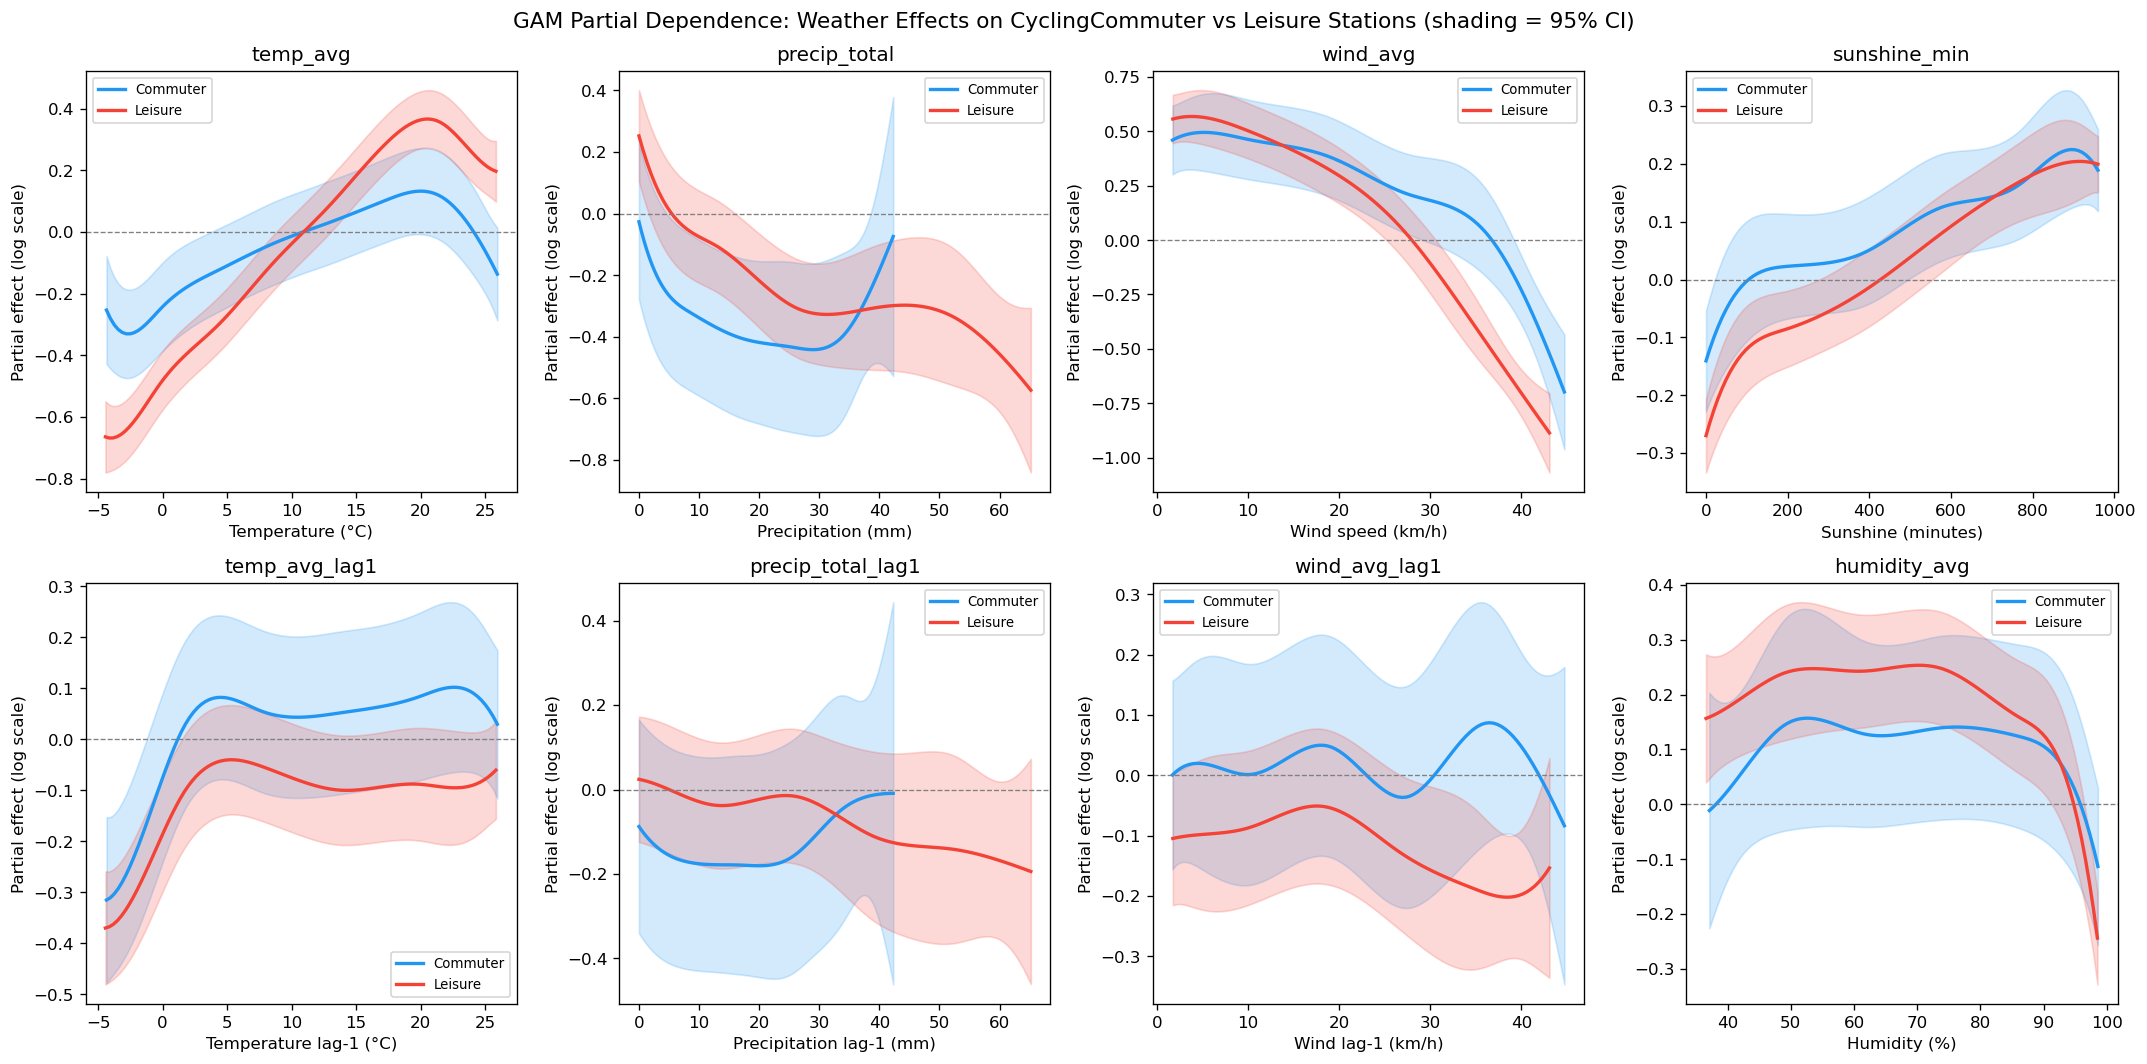

08_gam_partial_dependence saved.


In [101]:
fig, axes = plt.subplots(2, 4, figsize=(18, 9))

weather_terms = [
    (0, "temp_avg",           "Temperature (°C)",        axes[0, 0]),
    (1, "precip_total",       "Precipitation (mm)",       axes[0, 1]),
    (2, "wind_avg",           "Wind speed (km/h)",        axes[0, 2]),
    (3, "sunshine_min",       "Sunshine (minutes)",       axes[0, 3]),
    (5, "temp_avg_lag1",      "Temperature lag-1 (°C)",  axes[1, 0]),
    (6, "precip_total_lag1",  "Precipitation lag-1 (mm)", axes[1, 1]),
    (7, "wind_avg_lag1",      "Wind lag-1 (km/h)",        axes[1, 2]),
    (4, "humidity_avg",       "Humidity (%)",             axes[1, 3]),
]

def inv_x(XX, term_idx, scaler_obj):
    """Inverse-transform one column of a GAM grid back to original units."""
    dummy = np.zeros((len(XX), len(continuous_idx)))
    dummy[:, term_idx] = XX[:, term_idx]
    return scaler_obj.inverse_transform(dummy)[:, term_idx]

for term_idx, feat_name, xlabel, ax in weather_terms:
    XX_c = gam_commuter.generate_X_grid(term=term_idx)
    XX_l = gam_leisure.generate_X_grid(term=term_idx)

    pdep_c, confi_c = gam_commuter.partial_dependence(term=term_idx, X=XX_c, width=0.95)
    pdep_l, confi_l = gam_leisure.partial_dependence(term=term_idx, X=XX_l, width=0.95)

    # Convert scaled grid values back to original units for x-axis display
    x_c = inv_x(XX_c, term_idx, scaler_c)
    x_l = inv_x(XX_l, term_idx, scaler_l)

    ax.plot(x_c, pdep_c, color=COLORS["commuter"], linewidth=2, label="Commuter")
    ax.fill_between(x_c, confi_c[:, 0], confi_c[:, 1], alpha=0.2, color=COLORS["commuter"])
    ax.plot(x_l, pdep_l, color=COLORS["leisure"],  linewidth=2, label="Leisure")
    ax.fill_between(x_l, confi_l[:, 0], confi_l[:, 1], alpha=0.2, color=COLORS["leisure"])

    ax.axhline(0, color="gray", linestyle="--", linewidth=0.8)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Partial effect (log scale)")
    ax.set_title(feat_name)
    ax.legend(fontsize=8)

fig.suptitle(
    "GAM Partial Dependence: Weather Effects on Cycling"
    "Commuter vs Leisure Stations (shading = 95% CI)",
    fontsize=13)
fig.tight_layout()
fig.savefig(FIGS / "08_gam_partial_dependence.png", dpi=150)
plt.show()
print("08_gam_partial_dependence saved.")

## 7. Weather-Normalized Cycling Index

Normalized cycling index saved.


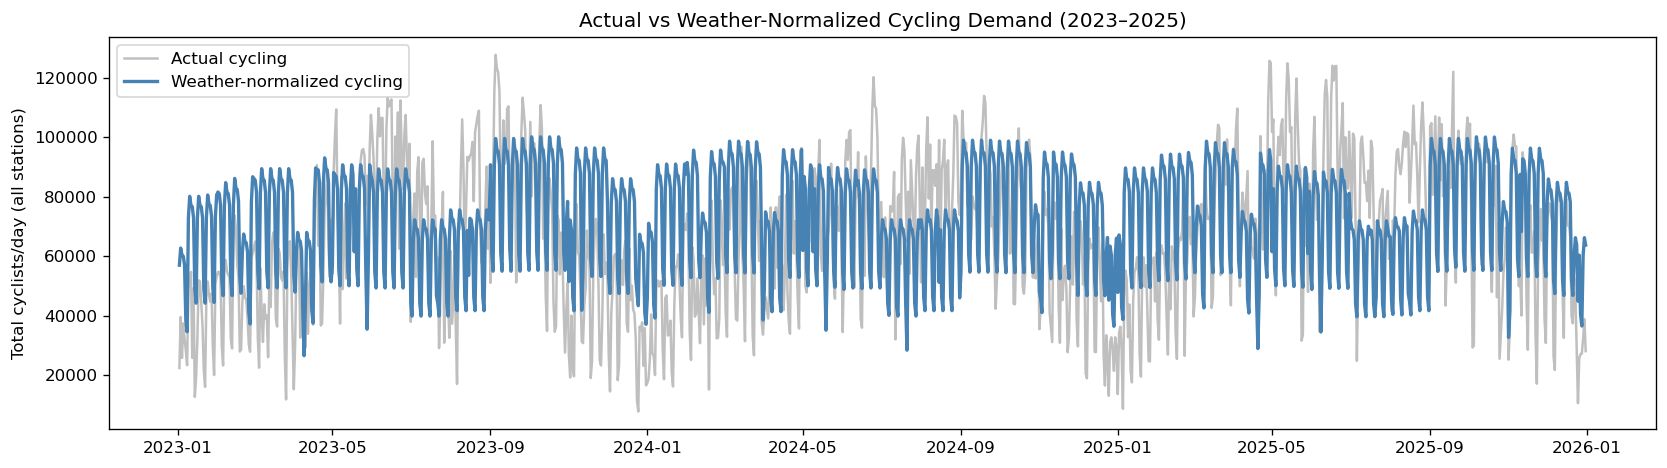

08_normalized_vs_actual saved.


In [100]:
ref_weather = {
    "temp_avg"          : 15.0,
    "precip_total"      : 0.0,
    "wind_avg"          : 10.0,
    "sunshine_min"      : 300.0,
    "humidity_avg"      : 70.0,
    "temp_avg_lag1"     : 15.0,
    "precip_total_lag1" : 0.0,
    "wind_avg_lag1"     : 10.0,
}

panel_norm = panel_good.copy()
panel_norm["date"] = pd.to_datetime(panel_norm["date"])
for col in ["is_weekend", "is_public_holiday", "is_school_holiday", "is_event_day"]:
    panel_norm[col] = panel_norm[col].astype(int)

cols_needed = ALL_FEATURES + ["site_offset"]
panel_norm_clean = panel_norm[cols_needed + ["site ID", "naam", "date", "aantal", "site_type", "day_type", "season"]].dropna()

X_norm = panel_norm_clean[ALL_FEATURES].values.copy().astype(float)
for feat, val_ref in ref_weather.items():
    idx = ALL_FEATURES.index(feat)
    X_norm[:, idx] = val_ref

X_norm_s = X_norm.copy()
X_norm_s[:, continuous_idx] = scaler.transform(X_norm[:, continuous_idx])

y_adj_pred = gam_full.predict(X_norm_s)
offset     = panel_norm_clean["site_offset"].values
panel_norm_clean = panel_norm_clean.copy()
panel_norm_clean["normalized_count"] = np.clip(np.expm1(y_adj_pred + offset), 0, None)

panel_norm_clean[["site ID", "naam", "date", "aantal",
                   "normalized_count", "site_type",
                   "day_type", "season"]].to_parquet(
    PROCESSED / "normalized_cycling.parquet", index=False
)
print("Normalized cycling index saved.")

daily_actual = panel_norm_clean.groupby("date")["aantal"].sum()
daily_norm   = panel_norm_clean.groupby("date")["normalized_count"].sum()

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(daily_actual.index, daily_actual.values, alpha=0.5, color="gray", label="Actual cycling")
ax.plot(daily_norm.index,   daily_norm.values,   color="steelblue", linewidth=2, label="Weather-normalized cycling")
ax.set_title("Actual vs Weather-Normalized Cycling Demand (2023\u20132025)")
ax.set_ylabel("Total cyclists/day (all stations)")
ax.legend()
fig.tight_layout()
fig.savefig(FIGS / "08_normalized_vs_actual.png", dpi=150)
plt.show()
print("08_normalized_vs_actual saved.")


**1. Weather is the primary driver of seasonal fluctuations**

The seasonal amplitude of the actual cycling curve (grey) is far larger than the normalized curve (blue). During winter months, actual counts fall substantially below normalized levels, indicating that the winter cycling drop is largely attributable to adverse weather conditions (low temperatures, rain) rather than a genuine collapse in underlying demand.

**2. Calendar effects are fully preserved after normalization**

The blue curve retains a clear high-frequency oscillation throughout the entire period. This reflects the day-of-week effect (weekend peaks vs. weekday troughs). Since normalization only removes weather variation, calendar signals remain intact in the normalized counts — consistent with model expectations.

**3. No evident growth trend in baseline cycling demand across three years**

The normalized curve holds a broadly stable mid-range level (~60,000–90,000 cyclists/day across all stations) from 2023 through 2025, with no sustained upward trend. Under the assumption of identical reference weather conditions, the underlying cycling demand at AWV stations appears structurally stable over this period.

**4. Favourable summers generate a weather bonus above the reference level**
   
During spring–summer 2023 and summer 2024, the actual curve periodically exceeds the normalized curve, indicating that real weather conditions on those days were better than the reference scenario (15 °C, 0 mm rain, 300 min sunshine, 10 km/h wind), producing additional weather-driven cycling above the modelled baseline.

**5. The late-2024 / early-2025 dip is weather-driven, not structural**
   
A pronounced trough is visible in the actual curve around December 2024 – January 2025, while the normalized curve remains relatively flat over the same period. This confirms the dip was caused by an episode of severe weather (cold spell or persistent rain) rather than a structural decline in cycling demand.

## 8. Weather Effect Magnitudes

In [103]:
# Representative mean offset for each model's training subset
mean_offset   = train["site_offset"].dropna().mean()
mean_offset_c = train_c["site_offset"].dropna().mean()
mean_offset_l = train_l["site_offset"].dropna().mean()

def weather_effect(gam, ref_row, feature_idx, bad_val, ref_val, scaler_obj, offset):
    X_bad = ref_row.copy()
    X_ref = ref_row.copy()
    if feature_idx in continuous_idx:
        pos = continuous_idx.index(feature_idx)
        X_bad[feature_idx] = (bad_val - scaler_obj.mean_[pos]) / scaler_obj.scale_[pos]
        X_ref[feature_idx] = (ref_val - scaler_obj.mean_[pos]) / scaler_obj.scale_[pos]
    else:
        X_bad[feature_idx] = bad_val
        X_ref[feature_idx] = ref_val
    # Back-transform from log-adjusted space to original count scale, then compute % change
    y_bad = np.expm1(gam.predict(X_bad.reshape(1, -1))[0] + offset)
    y_ref = np.expm1(gam.predict(X_ref.reshape(1, -1))[0] + offset)
    return (y_bad - y_ref) / y_ref * 100

ref_row   = X_train_s.mean(axis=0)
ref_row_c = X_train_cs.mean(axis=0)
ref_row_l = X_train_ls.mean(axis=0)

comparisons = [
    ("Heavy rain (20mm vs 0mm)",    1, 20.0,   0.0),
    ("Light rain (2mm vs 0mm)",     1,  2.0,   0.0),
    ("Cold day (0°C vs 15°C)",   0,  0.0,  15.0),
    ("Cool day (8°C vs 15°C)",   0,  8.0,  15.0),
    ("Strong wind (40 vs 10 km/h)", 2, 40.0,  10.0),
    ("No sunshine (0 vs 300 min)",  3,  0.0, 300.0),
]

print("" + "=" * 55)
print("GAM WEATHER EFFECT SIZES")
print("=" * 55)
print(f"{'Condition':<35} | {'Full':>7} | {'Commuter':>9} | {'Leisure':>8}")
print("-" * 68)
for label, feat_idx, bad_val, ref_val in comparisons:
    eff_full = weather_effect(gam_full,     ref_row,   feat_idx, bad_val, ref_val, scaler,   mean_offset)
    eff_c    = weather_effect(gam_commuter, ref_row_c, feat_idx, bad_val, ref_val, scaler_c, mean_offset_c)
    eff_l    = weather_effect(gam_leisure,  ref_row_l, feat_idx, bad_val, ref_val, scaler_l, mean_offset_l)
    print(f"{label:<35} | {eff_full:>6.1f}% | {eff_c:>8.1f}% | {eff_l:>7.1f}%")

GAM WEATHER EFFECT SIZES
Condition                           |    Full |  Commuter |  Leisure
--------------------------------------------------------------------
Heavy rain (20mm vs 0mm)            |  -33.5% |    -32.5% |   -37.6%
Light rain (2mm vs 0mm)             |  -10.5% |    -12.3% |   -11.6%
Cold day (0°C vs 15°C)              |  -37.4% |    -26.5% |   -48.6%
Cool day (8°C vs 15°C)              |  -18.0% |    -10.7% |   -26.7%
Strong wind (40 vs 10 km/h)         |  -58.9% |    -50.1% |   -70.3%
No sunshine (0 vs 300 min)          |  -15.6% |    -15.7% |   -19.4%


## 9. Save Models

In [105]:
#serialize the fitted GAM models and related objects for future use 
models = {
    "gam_full"     : gam_full,
    "gam_commuter" : gam_commuter,
    "gam_leisure"  : gam_leisure,
    "scaler"       : scaler,
    "scaler_c"     : scaler_c,
    "scaler_l"     : scaler_l,
    "site_log_mean": site_log_mean,
    "continuous_idx": continuous_idx,
    "ALL_FEATURES" : ALL_FEATURES,
}
with open(PROCESSED / "gam_models.pkl", "wb") as fh: 
    pickle.dump(models, fh)
print(f"Models saved to {PROCESSED / 'gam_models.pkl'}")


Models saved to /Users/queena/Documents/KU Leuven/Study material/Semester 1.2/Modern Analysis/Project/mda-cycling-weather-group6/data/processed/gam_models.pkl


## 10. Final Summary

In [108]:
heavy_rain_full = weather_effect(gam_full, ref_row, 1, 20.0,  0.0, scaler, mean_offset)
cold_day_full   = weather_effect(gam_full, ref_row, 0,  0.0, 15.0, scaler, mean_offset)
strong_wind_full= weather_effect(gam_full, ref_row, 2, 40.0, 10.0, scaler, mean_offset)

print("=" * 52)
print("GAM MODELLING SUMMARY")
print("=" * 52)
print(f"Training period : 2023–2024 ({len(y_train_adj):,} observations)")
print(f"Test period     : 2025     ({len(y_test_adj):,} observations)")
print()
print("Model performance (test set):")
print(f"  Full GAM     : MAE={test_mae:.1f}, R²={test_r2:.3f}")
print(f"  Commuter GAM : MAE={mae_c:.1f}, R²={r2_c:.3f}")
print(f"  Leisure GAM  : MAE={mae_l:.1f}, R²={r2_l:.3f}")
print()
print("Key weather effects on cycling demand (full model):")
print(f"  Heavy rain (20mm) : {heavy_rain_full:+.1f}%")
print(f"  Cold day (0°C)    : {cold_day_full:+.1f}%")
print(f"  Strong wind       : {strong_wind_full:+.1f}%")

GAM MODELLING SUMMARY
Training period : 2023–2024 (96,057 observations)
Test period     : 2025     (48,148 observations)

Model performance (test set):
  Full GAM     : MAE=139.4, R²=0.818
  Commuter GAM : MAE=125.1, R²=0.821
  Leisure GAM  : MAE=163.2, R²=0.691

Key weather effects on cycling demand (full model):
  Heavy rain (20mm) : -33.5%
  Cold day (0°C)    : -37.4%
  Strong wind       : -58.9%
